# Sequence to Sequence (Seq2Seq)

## Definition
Sequence-to-Sequence (Seq2Seq) is a neural network framework designed to transform one sequence into another, where the input and output sequences can have different lengths. Introduced by Sutskever et al. (2014), it uses an Encoder-Decoder architecture — the encoder compresses the input sequence into a fixed-length context vector, and the decoder generates the output sequence from that vector.

## Why It Is Needed
- **Variable-Length I/O:** Standard networks require fixed-size input/output — Seq2Seq handles sequences of arbitrary and differing lengths.
- **Conditional Generation:** The decoder generates output conditioned on the encoded representation of the entire input, enabling translation, summarization, and dialogue.
- **Foundation for Modern NLP:** Seq2Seq with Attention directly inspired the Transformer architecture that powers all modern LLMs.

## Real-World Applications
- Machine Translation (English → French)
- Text Summarization (long document → short summary)
- Dialogue systems and chatbot response generation
- Code generation from natural language descriptions
- Image captioning (CNN encoder + LSTM decoder)

## Important Points
- **Encoder:** Reads the full input sequence and compresses it into a fixed-size context vector (final hidden state).
  - Typically an LSTM or GRU.
- **Context Vector (Thought Vector):** The encoder's final hidden state — a bottleneck representation of the entire input.
- **Decoder:** An autoregressive RNN/LSTM that generates one output token at a time, conditioned on the context vector and previously generated tokens.
- **Teacher Forcing:** During training, the decoder receives the actual ground-truth previous token as input instead of its own previous prediction — speeds up training.
- **Bottleneck Problem:** The entire input sequence is compressed into a single fixed-size vector — information loss increases with sequence length.
- **Attention Mechanism:** Introduced to address the bottleneck — allows the decoder to dynamically attend to different parts of the encoder's output at each decoding step.

## Visual Understanding
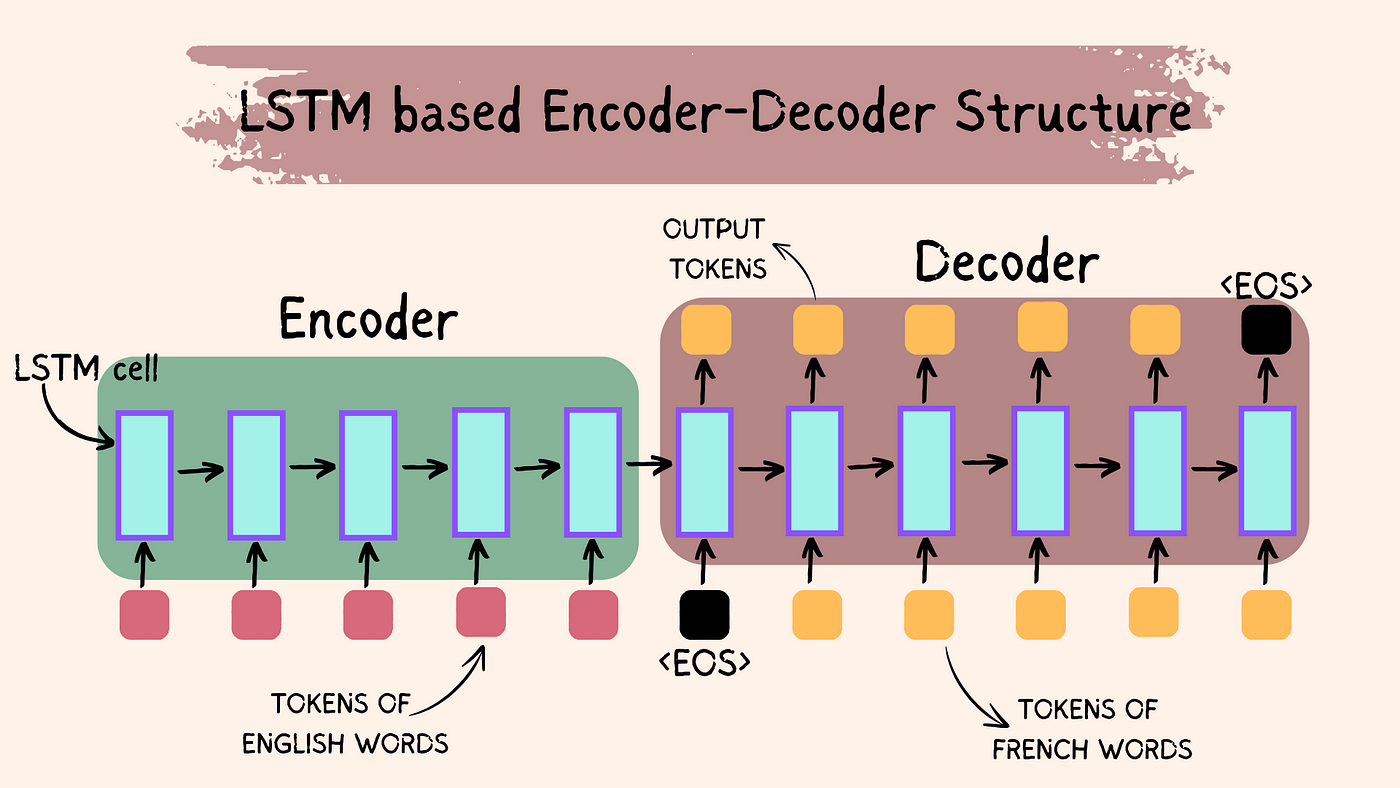

## Implementation
Practical implementation will be added here.

## Key Takeaways
- Seq2Seq maps variable-length input sequences to variable-length output sequences.
- The encoder compresses the input into a context vector; the decoder generates output from it.
- Teacher forcing accelerates decoder training by providing ground-truth previous tokens.
- The fixed context vector bottleneck is the primary limitation of vanilla Seq2Seq.
- Seq2Seq + Attention was the direct precursor to the Transformer architecture.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class Encoder(Model):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.embed = layers.Embedding(vocab_size, emb_dim)
        self.rnn = layers.GRU(hidden_dim, return_state=True, return_sequences=True)

    def call(self, x):
        x = self.embed(x)
        output, hidden = self.rnn(x)
        return hidden

class Decoder(Model):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embed = layers.Embedding(vocab_size, emb_dim)
        self.rnn = layers.GRU(hidden_dim, return_state=True, return_sequences=True)
        self.fc = layers.Dense(vocab_size)

    def call(self, x, hidden):
        x = self.embed(x)
        output, hidden = self.rnn(x, initial_state=hidden)
        return self.fc(output), hidden

class Seq2Seq(Model):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, src, tgt):
        hidden = self.encoder(src)
        output, _ = self.decoder(tgt, hidden)
        return output

# Example usage
vocab_size = 10000  # Example vocab size
emb_dim = 256       # Example embedding dimension
hidden_dim = 512    # Example hidden dimension

encoder = Encoder(vocab_size, emb_dim, hidden_dim)
decoder = Decoder(vocab_size, emb_dim, hidden_dim)
seq2seq = Seq2Seq(encoder, decoder)

# Random input sequences: batch_size=2, sequence_length=5 (for simplicity)
src = tf.random.uniform((2, 5), minval=0, maxval=vocab_size, dtype=tf.int32)  # Source sequence (batch_size=2, seq_len=5)
tgt = tf.random.uniform((2, 5), minval=0, maxval=vocab_size, dtype=tf.int32)  # Target sequence (batch_size=2, seq_len=5)

# Show input sequences
print("Source Sequence (src):")
print(src)
print("Target Sequence (tgt):")
print(tgt)

# Forward pass through Seq2Seq model
output = seq2seq(src, tgt)

# Show output shape and some sample values
print("\nOutput Shape:")
print(output.shape)  # Expected: (batch_size, seq_len, vocab_size)

# Show the output values for inspection (for a more realistic scenario, you would pass through softmax layer for probabilities)
print("\nOutput (before softmax):")
print(output)

Source Sequence (src):
tf.Tensor(
[[4282 6883 8253 3680 5773]
 [ 622 5774 9259 4044 8007]], shape=(2, 5), dtype=int32)
Target Sequence (tgt):
tf.Tensor(
[[1229 2292 1321 6478 5968]
 [8997 7252 1391 1152 6234]], shape=(2, 5), dtype=int32)

Output Shape:
(2, 5, 10000)

Output (before softmax):
tf.Tensor(
[[[ 0.00023152  0.00036751  0.00580649 ...  0.00133648 -0.00014612
   -0.00182201]
  [-0.00138948 -0.00268177 -0.0008823  ...  0.00316981  0.00413238
   -0.00082111]
  [-0.00474558 -0.00356304  0.00091932 ...  0.00477495  0.00299576
   -0.00019762]
  [ 0.00275621 -0.0026377   0.00417847 ... -0.00139687 -0.00213797
    0.00158448]
  [ 0.00095046 -0.00352572 -0.00298803 ...  0.00140957  0.00222611
    0.00345636]]

 [[-0.00293655  0.00541074  0.0012671  ...  0.00159937  0.00400032
   -0.00195865]
  [-0.00218288  0.00186938 -0.00458215 ...  0.00118869  0.00689738
   -0.00039638]
  [-0.00051523 -0.00262186 -0.0012761  ...  0.00489513  0.00059553
   -0.00020457]
  [-0.00354018 -0.00196027 -0.